## Exploration

In [1]:
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import re
%matplotlib inline

In [2]:
# dataset source: https://www.data.gouv.fr/api/1/datasets/r/f5df602b-3800-44d7-b2df-fa40a0350325
# Load dataset
df = pd.read_csv("communes-france-2025.csv", dtype=str)

# Extract names from second column (index 1)
names_all = df.iloc[:, 2].tolist()

# Clean: remove parentheses and content inside
names_clean = [re.sub(r'\s*\([^)]*\)', '', name).strip() for name in names_all] # e.g. 'Bors (Canton de Tude-et-Lavalette)', 'Bors (Canton de Charente-Sud)'

# Remove duplicates
names_unique = list[str](set[str](names_clean))

# Save cleaned unique names
with open('french_communes.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(sorted(names_unique)))

print(f"Original: {len(names_all)} names")
print(f"Cleaned: {len(names_unique)} names, removed {len(names_all)-len(names_unique)} duplicate names")
print(f"Longest name has {len(max(names_unique, key=len))} characters: {max(names_unique, key=len)}")
print(f"First few names: {names_unique[:5]}")

names = names_unique

Original: 34935 names
Cleaned: 32684 names, removed 2251 duplicate names
Longest name has 45 characters: Saint-Remy-en-Bouzemont-Saint-Genest-et-Isson
First few names: ['Locmiquélic', 'Le Ployron', 'Mouilly', 'Kourou', 'Saint-Berthevin']


In [59]:
# Build the vocabulary of characters and mappings to and from integers

chars = sorted(list(set(''.join(names))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0 # the dot is the "start" and "end" character
itos = {i:s for s,i in stoi.items()}
print(itos)
print(names[:3])
print(len(itos))

{1: ' ', 2: "'", 3: '-', 4: 'A', 5: 'B', 6: 'C', 7: 'D', 8: 'E', 9: 'F', 10: 'G', 11: 'H', 12: 'I', 13: 'J', 14: 'K', 15: 'L', 16: 'M', 17: 'N', 18: 'O', 19: 'P', 20: 'Q', 21: 'R', 22: 'S', 23: 'T', 24: 'U', 25: 'V', 26: 'W', 27: 'X', 28: 'Y', 29: 'Z', 30: 'a', 31: 'b', 32: 'c', 33: 'd', 34: 'e', 35: 'f', 36: 'g', 37: 'h', 38: 'i', 39: 'j', 40: 'k', 41: 'l', 42: 'm', 43: 'n', 44: 'o', 45: 'p', 46: 'q', 47: 'r', 48: 's', 49: 't', 50: 'u', 51: 'v', 52: 'w', 53: 'x', 54: 'y', 55: 'z', 56: 'È', 57: 'É', 58: 'Î', 59: 'Ô', 60: 'à', 61: 'â', 62: 'ç', 63: 'è', 64: 'é', 65: 'ê', 66: 'ë', 67: 'î', 68: 'ï', 69: 'ô', 70: 'û', 71: 'ü', 72: 'ÿ', 73: 'Œ', 74: 'œ', 0: '.'}
['Locmiquélic', 'Le Ployron', 'Mouilly']
75


In [ ]:
# Build the dataset

context_length = 45

X, Y = [], []
for n in names:
    context = [0] * context_length
    for c in n + '.':
        ix = stoi[c]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

In [130]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([424207, 10]), torch.int64, torch.Size([424207]), torch.int64)

In [ ]:
n_embed = 2 # embedding dimension of our characters. 2 is low, but will allow us to show our chars visibly

# Build the (randomly initialized) embedding lookup table, which is trainable
C = torch.randn((len(stoi), n_embed)) # ((75, 2))

In [34]:
# example: the embeddings of the first name

print(names[0]) # first name

indices = []
for c in names[0]:
    indices.append(stoi[c])

print(indices) # indices of the first name

C[indices] # the embeddings of the first name

Ambrus
[4, 42, 31, 47, 50, 48]


tensor([[ 0.4934, -1.7882],
        [ 1.9150,  1.4024],
        [ 1.4146,  0.1747],
        [ 0.6267,  0.2726],
        [-0.9746,  0.6287],
        [-0.1082, -0.7879]])

In [ ]:
# embed all our training examples:

emb = C[X]
emb.shape # (391523 training examples, 3 context characters, 2 embedding dimensions)

torch.Size([391523, 3, 2])

In [47]:
n_hidden = 128

W1 = torch.randn((context_length * n_embed, n_hidden)) # ((3*2=6, 128))
b1 = torch.randn((n_hidden)) # (128)

# emb @ W1 + b1
# (391523, 3, 2) @ (6, 128) + (128)

emb.view(-1, context_length * n_embed).shape # (391523, 6)

torch.Size([391523, 6])

In [ ]:
# create the hidden layer: (391523, 128) @ (128, 75) + (75)

h = torch.tanh(emb.view(-1, context_length * n_embed) @ W1 + b1)
h.shape # (391523, 128)

# addition: 
# W1: (6, 128)
# b1: (1, 128) # broadcasting aligns on the right, creates a fake dimension on the left, will copy vertically for every row


torch.Size([391523, 128])

In [ ]:
# create the output layer: h @ W2 + b2

W2 = torch.randn((n_hidden, len(stoi))) # (128, 75) (n_hidden, n_output_tokens)
b2 = torch.randn((len(stoi))) # (75)

# forward pass:
logits = h @ W2 + b2
logits.shape # (391523, 75)

logits[0] # first training example's logits


tensor([-10.2776,  14.2217,   2.2591,   0.3506,   7.1607, -12.5144, -22.2599,
         -1.0002,   2.6145,  -8.0621,  -1.1857,  11.0325,  -2.4688,   3.2093,
         -8.7488, -20.8523,   4.2462,   4.2306, -12.4899,  -6.7872,  -5.1026,
         -6.7895, -12.0215, -12.9358,  12.1943, -19.2147, -15.1541, -16.3256,
         -1.4823, -12.7740,  -4.1580,   0.2179,  19.8339,   8.6407,  15.9864,
         -6.4111,  17.5455,  11.6137,   0.3896,  -7.4392,  13.3273,  -7.4933,
         10.2827,   1.6405, -12.0439, -11.7539,  -3.3211,   7.4869,   0.6580,
         -2.3308,  15.4392,  -6.9287,  11.2154,  -6.0537,  -3.7655,   1.3504,
          3.7133,   4.6420,   6.2028, -14.4477,  -0.6563,  -7.8064,  -8.1833,
         13.8187,  -5.6621,  -9.7352,  17.6659,  -7.4653,  11.5994,  -5.9700,
        -18.6040, -14.4568, -12.8797, -15.0910,  -3.9596])

In [ ]:
prob = logits.exp() / logits.exp().sum(dim=-1, keepdim=True) # equivalent of F.softmax(logits, dim=-1)
prob.shape # (391523, 75)

tensor(-9.7811)

In [ ]:
# example: the loss of the first training example
print(prob[0]) # first training example's probabilities
loss = -prob[0, Y[0]].log() # loss of first training example
print(loss)


tensor([6.6509e-14, 2.9027e-03, 1.8514e-08, 2.7457e-09, 2.4903e-06, 7.1030e-15,
        4.1596e-19, 7.1127e-10, 2.6414e-08, 6.0964e-13, 5.9083e-10, 1.1961e-04,
        1.6376e-10, 4.7884e-08, 3.0677e-13, 1.6995e-18, 1.3505e-07, 1.3297e-07,
        7.2797e-15, 2.1814e-12, 1.1759e-11, 2.1764e-12, 1.1629e-14, 4.6604e-15,
        3.8220e-04, 8.7405e-18, 5.0707e-16, 1.5713e-16, 4.3919e-10, 5.4792e-15,
        3.0242e-11, 2.4045e-09, 7.9457e-01, 1.0939e-05, 1.6951e-02, 3.1774e-12,
        8.0593e-02, 2.1387e-04, 2.8550e-09, 1.1365e-12, 1.1867e-03, 1.0767e-12,
        5.6509e-05, 9.9739e-09, 1.1371e-14, 1.5197e-14, 6.9835e-11, 3.4507e-06,
        3.7338e-09, 1.8800e-10, 9.8076e-03, 1.8936e-12, 1.4361e-04, 4.5424e-12,
        4.4776e-11, 7.4622e-09, 7.9263e-08, 2.0062e-07, 9.5547e-07, 1.0276e-15,
        1.0032e-09, 7.8729e-13, 5.4004e-13, 1.9399e-03, 6.7201e-12, 1.1440e-13,
        9.0908e-02, 1.1073e-12, 2.1085e-04, 4.9390e-12, 1.6098e-17, 1.0183e-15,
        4.9297e-15, 5.4005e-16, 3.6878e-

In [70]:
# negative log likelihood loss:
loss = -prob[torch.arange(prob.shape[0]), Y].log().mean() # negative log likelihood loss
loss

tensor(25.4637)

## Actual code

In [ ]:
# Hyperparameters

# context_length = 10
# n_embed = 10
# n_hidden = 128

# val loss: 2.15

# context_length = 15 # 
# n_embed = 16
# n_hidden = 64
# minibatch_size = 64

# # val loss: 2.45

# context_length = 10 # longest name in our dataset
# n_embed = 16
# n_hidden = 128
# minibatch_size = 128

# val loss: 2.16

# context_length = 10 
# n_embed = 32
# n_hidden = 128
# minibatch_size = 32

# val loss: 2.12

context_length = 8 
n_embed = 64
n_hidden = 128
minibatch_size = 32

# val loss: 2.03


In [67]:
# Rebuild the dataset (in case you use a different context length)

X, Y = [], []
for n in names:
    context = [0] * context_length
    for c in n + '.':
        ix = stoi[c]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

# Split the data into training and validation sets

Xtr = X[:int(0.9*len(X))]
Ytr = Y[:int(0.9*len(Y))]
Xval = X[int(0.9*len(X)):]
Yval = Y[int(0.9*len(Y)):]

Xtr.shape, Ytr.shape, Xval.shape, Yval.shape

(torch.Size([381786, 8]),
 torch.Size([381786]),
 torch.Size([42421, 8]),
 torch.Size([42421]))

In [68]:
# Model

C = torch.randn((len(stoi), n_embed)) # ((75, n_embed)) lookup table for embeddings
W1 = torch.randn((context_length * n_embed, n_hidden)) # ((context_length*n_embed, n_hidden))
b1 = torch.randn((n_hidden)) # (n_hidden)
W2 = torch.randn((n_hidden, len(stoi))) # (n_hidden, 75)
b2 = torch.randn((len(stoi))) # (75)

parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lri = []
lossi = []
stepi = []

In [69]:
for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (minibatch_size,))
  
  # forward pass
  emb = C[Xtr[ix]] # (batch_size, context_length, n_embed)
  h = torch.tanh(emb.view(-1, context_length * n_embed) @ W1 + b1) # (batch_size, n_hidden)
  logits = h @ W2 + b2 # (batch_size, len(stoi))
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

  if i % 10000 == 0:
    # compute validation loss
    emb_val = C[Xval]
    h_val = torch.tanh(emb_val.view(-1, context_length * n_embed) @ W1 + b1)
    logits_val = h_val @ W2 + b2
    val_loss = F.cross_entropy(logits_val, Yval)
    print(f"step {i:>6d} | train loss {loss.item():.4f} | val loss {val_loss.item():.4f}")

step      0 | train loss 30.9039 | val loss 26.7504
step  10000 | train loss 2.3448 | val loss 2.7625
step  20000 | train loss 2.3923 | val loss 2.4891
step  30000 | train loss 2.6179 | val loss 2.3520
step  40000 | train loss 2.0410 | val loss 2.2777
step  50000 | train loss 2.3769 | val loss 2.2635
step  60000 | train loss 1.9966 | val loss 2.2341
step  70000 | train loss 2.4949 | val loss 2.1893
step  80000 | train loss 1.7300 | val loss 2.1828
step  90000 | train loss 2.2248 | val loss 2.1460
step 100000 | train loss 2.2209 | val loss 2.1183
step 110000 | train loss 2.0177 | val loss 2.0533
step 120000 | train loss 1.7866 | val loss 2.0483
step 130000 | train loss 1.8990 | val loss 2.0462
step 140000 | train loss 1.7263 | val loss 2.0444
step 150000 | train loss 1.6798 | val loss 2.0446
step 160000 | train loss 2.3868 | val loss 2.0421
step 170000 | train loss 1.7633 | val loss 2.0389
step 180000 | train loss 1.8251 | val loss 2.0408
step 190000 | train loss 2.1071 | val loss 2.038

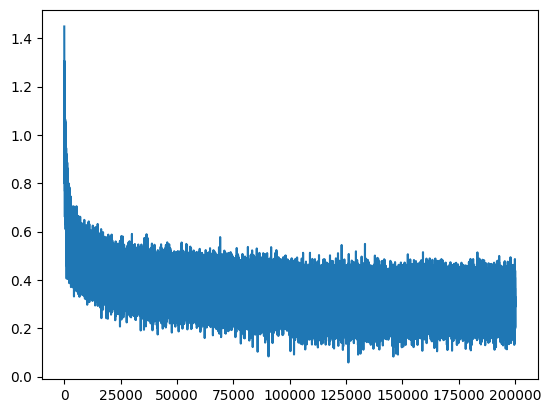

In [55]:
plt.plot(stepi, lossi)

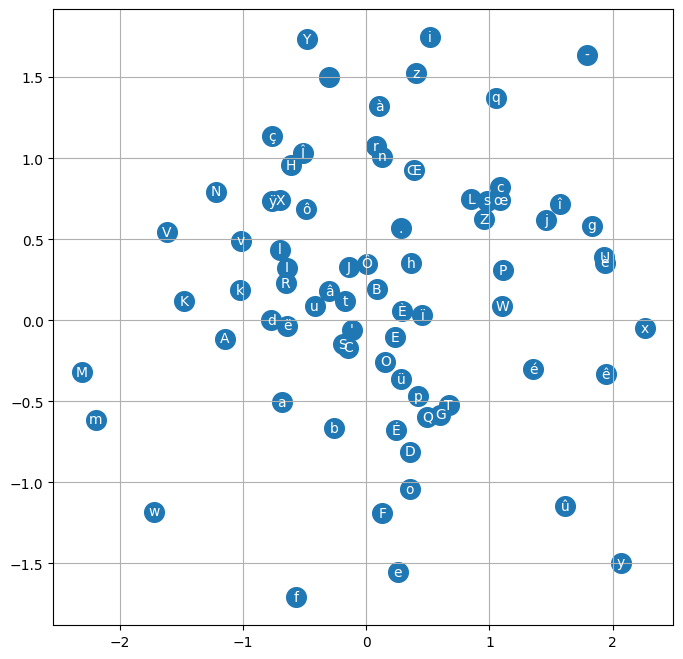

In [72]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [71]:
# sample from the model

for _ in range(20):
    
    out = []
    context = [0] * context_length # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

Andix.
La Ban.
Sainx.
Nod.
Seurgcourt.
Samat-Prixrher.
AOvi.
Saint-Jroné.
Etilaiv.
Lépantfais.
Boint.
Villy-Bo.
Nentllams-sur-Rozièra.
Lupduville.
Pordathe.
Chandans.
Pellillebrincherelle.
Nouville-en-Payele.
Cheuignon-es-Villers.
Sarzaueqre.
